In [1]:
import rioxarray as rioxr
import matplotlib.pyplot as plt
import oggm
from oggm import cfg, utils, workflow, tasks, graphics
from oggm.core import gis
cfg.initialize(logging_level='WARNING')
cfg.PARAMS['border'] = 10

2024-10-04 14:49:18: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2024-10-04 14:49:18: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2024-10-04 14:49:18: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2024-10-04 14:49:18: oggm.cfg: PARAMS['border'] changed from `80` to `10`.


2024-10-04 14:54:11: oggm.workflow: Execute entity tasks [GlacierDirectory] on 1 glaciers


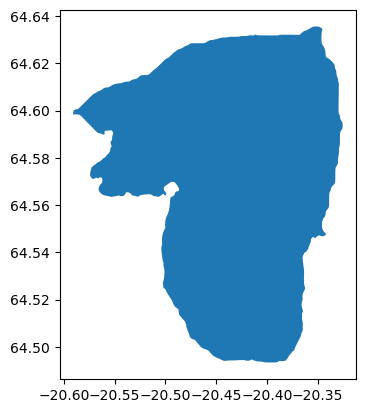

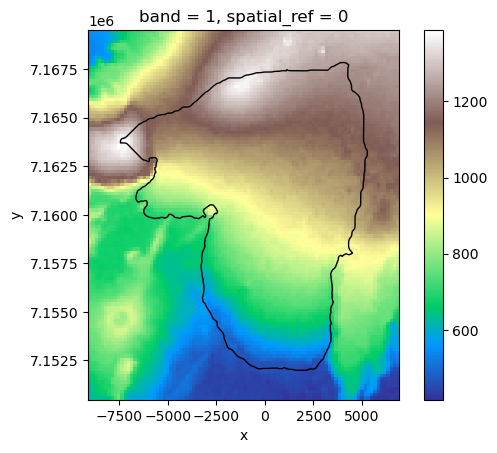

In [8]:
entity = utils.get_rgi_glacier_entities(['RGI60-06.00291'])
entity.plot();
# Let's make a working directory for this DEM 
cfg.PATHS['working_dir'] = utils.gettempdir('default', reset=True)
gdir = workflow.init_glacier_directories(entity)[0]
tasks.define_glacier_region(gdir, source='ASTER')
dem_path = gdir.get_filepath('dem')
dem_path
da = rioxr.open_rasterio(dem_path)
f, ax = plt.subplots()
da.plot(cmap='terrain', ax=ax);
# Add the outlines
gdir.read_shapefile('outlines').plot(ax=ax, color='none', edgecolor='black');